# Rainfall Prediction Classifier

## 👨‍💻 Executive Summary
The goal of this project is to build a classifier to predict rainfall in Australia. Unlike standard models, this project focuses on handling class imbalance (non-rainy days outnumber rainy days) and optimizing for F1-score to ensure reliable predictions for stakeholders.

---
*Original lab framework provided by IBM Skills Network. Technical implementation, 
statistical analysis, and visualizations performed by [Roberto Castro / rcastro-ai](https://github.com/rcastro-ai)*

# Building a Rainfall Prediction Classifier

## Change History
    
| Version | Description |
| :------ | :---------- |
| v1      | Initial version including Random Forest, Logistic Regression, and SVM models |
| v2      | Set the seed at 42 so the results can be recreated in any subsequent execution |
| v3      | Added XGBoost model, change history table, and the list of best parameters for each model |
| v4      | Included table explaining the four models used in this project |


## Objectives

* Explore and perform feature engineering on a real-world data set
* Build a classifier pipeline and optimize it using grid search cross validation
* Evaluate your model by interpreting various performance metrics and visualizations
* Implement a different classifier by updating the pipeline
* Use an appropriate set of parameters to search over in each case

## About The Dataset
The original source of the data is Australian Government's Bureau of Meteorology and the latest data can be gathered from [http://www.bom.gov.au/climate/dwo/](http://www.bom.gov.au/climate/dwo/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2022-01-01).

* **Data Source:** [Australian Government's Bureau of Meteorology](http://www.bom.gov.au/climate/dwo/)

* **Kaggle Source:** [Weather Dataset (Rattle Package)](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package/)

* **Column Definitions:** [BOM Metadata Guide](http://www.bom.gov.au/climate/dwo/IDCJDW0000.shtml?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2022-01-01)

The dataset contains observations of weather metrics for each day from 2008 to 2017, and includes the following fields:

| Field         | Description                                           | Unit            | Type   |
| :------------ | :---------------------------------------------------- | :-------------- | :----- |
| Date          | Date of the Observation in YYYY-MM-DD                 | Date            | object |
| Location      | Location of the Observation                           | Location        | object |
| MinTemp       | Minimum temperature                                   | Celsius         | float  |
| MaxTemp       | Maximum temperature                                   | Celsius         | float  |
| Rainfall      | Amount of rainfall                                    | Millimeters     | float  |
| Evaporation   | Amount of evaporation                                 | Millimeters     | float  |
| Sunshine      | Amount of bright sunshine                             | hours           | float  |
| WindGustDir   | Direction of the strongest gust                       | Compass Points  | object |
| WindGustSpeed | Speed of the strongest gust                           | Kilometers/Hour | object |
| WindDir9am    | Wind direction averaged over 10 minutes prior to 9am  | Compass Points  | object |
| WindDir3pm    | Wind direction averaged over 10 minutes prior to 3pm  | Compass Points  | object |
| WindSpeed9am  | Wind speed averaged over 10 minutes prior to 9am      | Kilometers/Hour | float  |
| WindSpeed3pm  | Wind speed averaged over 10 minutes prior to 3pm      | Kilometers/Hour | float  |
| Humidity9am   | Humidity at 9am                                       | Percent         | float  |
| Humidity3pm   | Humidity at 3pm                                       | Percent         | float  |
| Pressure9am   | Atmospheric pressure reduced to mean sea level at 9am | Hectopascal     | float  |
| Pressure3pm   | Atmospheric pressure reduced to mean sea level at 3pm | Hectopascal     | float  |
| Cloud9am      | Fraction of the sky obscured by cloud at 9am          | Eights          | float  |
| Cloud3pm      | Fraction of the sky obscured by cloud at 3pm          | Eights          | float  |
| Temp9am       | Temperature at 9am                                    | Celsius         | float  |
| Temp3pm       | Temperature at 3pm                                    | Celsius         | float  |
| RainToday     | If there was at least 1mm of rain today               | Yes/No          | object |
| RainTomorrow  | If there is at least 1mm of rain tomorrow             | Yes/No          | object |



# Loading the Data and Performing Data Wrangling and EDA

## Importing the Required Libraries

In [1]:
# Importing the required libraries

import pandas as pd
import numpy as np
import xgboost as xgb
import sklearn
import random
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay
from xgboost import XGBClassifier
from packaging import version

In [2]:
# Setting the seed at 42

seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)

## Loading the Data

In [3]:
# Loading the data

#url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/_0eYOqji3unP1tDNKWZMjg/weatherAUS-2.csv"
#df = pd.read_csv(url)

# Environment Detection
if os.path.exists('/kaggle/input'):
    print("Running on Kaggle")
    # Update this with your specific Kaggle dataset path
    data_path = '/kaggle/input/datasets/robertocastro7/weather-aus/weather_AUS.csv'
elif os.path.exists('data/weather_AUS.csv'):
    print("Running locally (Anaconda/GitHub structure)")
    data_path = 'data/weather_AUS.csv'
else:
    print("Running locally (Root structure)")
    data_path = 'weather_AUS.csv'

df = pd.read_csv(data_path)

# Showing first 5 records
df.head()

Running locally (Anaconda/GitHub structure)


,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
# Saving original data locally

#data_file = Path.cwd() / "data" / "weather_AUS.csv"

#df.to_csv(data_file)

In [5]:
# Showing the number of observations by attribute

df.count()

Unnamed: 0       145460
Date             145460
Location         145460
MinTemp          143975
MaxTemp          144199
Rainfall         142199
Evaporation       82670
Sunshine          75625
WindGustDir      135134
WindGustSpeed    135197
WindDir9am       134894
WindDir3pm       141232
WindSpeed9am     143693
WindSpeed3pm     142398
Humidity9am      142806
Humidity3pm      140953
Pressure9am      130395
Pressure3pm      130432
Cloud9am          89572
Cloud3pm          86102
Temp9am          143693
Temp3pm          141851
RainToday        142199
RainTomorrow     142193
dtype: int64

Sunshine and cloud cover seem like important features, but they have a lot of missing values, far too many to impute their missing values.


### Dropping all rows with missing values
To try to keep things simple we'll drop rows with missing values and see what's left.

In [6]:
# Dropping all the observations that have missing values and showing the information of the resulting dataframe

df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56420 entries, 6049 to 142302
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     56420 non-null  int64  
 1   Date           56420 non-null  object 
 2   Location       56420 non-null  object 
 3   MinTemp        56420 non-null  float64
 4   MaxTemp        56420 non-null  float64
 5   Rainfall       56420 non-null  float64
 6   Evaporation    56420 non-null  float64
 7   Sunshine       56420 non-null  float64
 8   WindGustDir    56420 non-null  object 
 9   WindGustSpeed  56420 non-null  float64
 10  WindDir9am     56420 non-null  object 
 11  WindDir3pm     56420 non-null  object 
 12  WindSpeed9am   56420 non-null  float64
 13  WindSpeed3pm   56420 non-null  float64
 14  Humidity9am    56420 non-null  float64
 15  Humidity3pm    56420 non-null  float64
 16  Pressure9am    56420 non-null  float64
 17  Pressure3pm    56420 non-null  float64
 18  Cloud9a

Since we still have 56k observations left after dropping missing values, we may not need to impute any missing values.  
Let's see how we do.


In [7]:
# Showing all attributes in the dataframe

df.columns

Index(['Unnamed: 0', 'Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall',
       'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am',
       'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

## Data Leakage Considerations
Consider the descriptions above for the columns in the data set. Are there any practical limitations to being able to predict whether it will rain tomorrow given the available data? 

At first it would seem that we have a case of feature redundancy when the data shows measurements of temperature, wind speed, wind direction, humidity, atmospheric pressure, and cloudiness at several points during the day and instead just rely on the daily measurements. However, in weather forecast capturing temporal trends to have information about changing weather patterns during the day can be a very good indicator of what could happen the next day. Unless we identify multicollinearity among these features, it would be beneficial for the model to keep all the features. One additional approach could be doing some feature engineering by combining some of these features into others that can provide that extra information. For this particular purpose, a correlation heatmap could be very useful.

We decide to predict today’s rainfall using historical weather data up to and including yesterday, then we can legitimately utilize all of the available features. This shift would be particularly useful for practical applications, such as deciding whether you will bike to work today.

With this new target, we should update the names of the rain columns accordingly to avoid confusion.


In [8]:
# Modifying the names of the columns related to rain

df = df.rename(columns={'RainToday': 'RainYesterday',
                        'RainTomorrow': 'RainToday'
                        })

## Data Granularity

Would the weather patterns have the same predictability in vastly different locations in Australia? I would think not.  
The chance of rain in one location can be much higher than in another. 
Using all of the locations requires a more complex model as it needs to adapt to local weather patterns.  
Let's see how many observations we have for each location, and see if we can reduce our attention to a smaller region.


## Location Selection
The location Watsonia is only 15 km from Melbourne, and the Melbourne Airport is only 18 km from Melbourne.  
We will group these three locations together and use only their weather data to build our localized prediction model.  
Because there might still be some slight variations in the weather patterns we'll keep `Location` as a categorical variable.

In [9]:
# Selecting three locations only

df = df[df.Location.isin(['Melbourne', 'MelbourneAirport', 'Watsonia'])]
df. info()

<class 'pandas.core.frame.DataFrame'>
Index: 7557 entries, 64191 to 80997
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     7557 non-null   int64  
 1   Date           7557 non-null   object 
 2   Location       7557 non-null   object 
 3   MinTemp        7557 non-null   float64
 4   MaxTemp        7557 non-null   float64
 5   Rainfall       7557 non-null   float64
 6   Evaporation    7557 non-null   float64
 7   Sunshine       7557 non-null   float64
 8   WindGustDir    7557 non-null   object 
 9   WindGustSpeed  7557 non-null   float64
 10  WindDir9am     7557 non-null   object 
 11  WindDir3pm     7557 non-null   object 
 12  WindSpeed9am   7557 non-null   float64
 13  WindSpeed3pm   7557 non-null   float64
 14  Humidity9am    7557 non-null   float64
 15  Humidity3pm    7557 non-null   float64
 16  Pressure9am    7557 non-null   float64
 17  Pressure3pm    7557 non-null   float64
 18  Cloud9am

We still have 7557 records, which should be enough to build a reasonably good model.  
We could always gather more data if needed by partioning the data into similar locations or simplyby updating it from the source to include a larger time frame.

## Extracting a Seasonality Feature
Now let's consider the `Date` column. We expect the weather patterns to be seasonal, having different predictablitiy levels in winter and summer for example.  
There may be some variation with `Year` as well, but we'll leave that out for now.
Let's engineer a `Season` feature from `Date` and drop `Date` afterward, since it is most likely less informative than season. 
An easy way to do this is to define a function that assigns seasons to given months, then use that function to transform the `Date` column.

### Create a function to map dates to seasons

In [10]:
# Creating a function to map dates to seasons

def date_to_season(date):
    month = date.month
    if (month == 12) or (month == 1) or (month == 2):
        return 'Summer'
    elif (month == 3) or (month == 4) or (month == 5):
        return 'Autumn'
    elif (month == 6) or (month == 7) or (month == 8):
        return 'Winter'
    elif (month == 9) or (month == 10) or (month == 11):
        return 'Spring'

### Map the dates to seasons and drop the Date column

In [11]:
# Mapping the dates to seasons and dropping the Date column

# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Apply the function to the 'Date' column
df['Season'] = df['Date'].apply(date_to_season)

df = df.drop(columns='Date')
df

,Unnamed: 0,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainYesterday,RainToday,Season
64191,64191,MelbourneAirport,11.2,19.9,0.0,5.6,8.8,SW,69.0,W,...,37.0,1005.1,1006.4,7.0,7.0,15.9,18.1,No,Yes,Summer
64192,64192,MelbourneAirport,7.8,17.8,1.2,7.2,12.9,SSE,56.0,SW,...,43.0,1018.0,1019.3,6.0,7.0,12.5,15.8,Yes,No,Summer
64193,64193,MelbourneAirport,6.3,21.1,0.0,6.2,10.5,SSE,31.0,E,...,35.0,1020.8,1017.6,1.0,7.0,13.4,19.6,No,No,Summer
64194,64194,MelbourneAirport,8.1,29.2,0.0,6.4,12.5,SSE,35.0,NE,...,23.0,1016.2,1012.8,5.0,4.0,16.0,28.2,No,No,Summer
64195,64195,MelbourneAirport,9.7,29.0,0.0,7.4,12.3,SE,33.0,SW,...,31.0,1011.9,1010.3,6.0,2.0,19.4,27.1,No,No,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80992,80992,Watsonia,3.6,14.5,0.0,2.4,8.8,NNE,41.0,ENE,...,66.0,1028.4,1025.0,1.0,7.0,5.2,13.8,No,No,Winter
80994,80994,Watsonia,4.8,13.3,0.4,0.6,0.0,NNW,24.0,NE,...,63.0,1028.5,1025.1,7.0,7.0,5.6,12.4,No,No,Winter
80995,80995,Watsonia,5.6,13.1,0.0,1.6,6.0,NNW,52.0,NE,...,67.0,1019.0,1014.0,1.0,7.0,8.8,11.6,No,Yes,Winter
80996,80996,Watsonia,6.9,12.1,3.2,1.8,5.6,SSW,24.0,WNW,...,61.0,1018.7,1017.3,2.0,7.0,7.9,11.0,Yes,No,Winter


Looks like we have a good set of features to work with. 

Let's go ahead and build our model.

But before doing that, let's take a look at how well balanced our target is.


# Building the Classifier Models
## Define the Feature and Target Dataframes

In [12]:
# Defining the feature and target dataframes

X = df.drop(columns=['RainToday'])
y = df['RainToday']

## But How Balanced are the Classes?

In [13]:
# Showing how balanced the classes are

y.value_counts()

RainToday
No     5766
Yes    1791
Name: count, dtype: int64

### Showing the class imbalance by using a plot

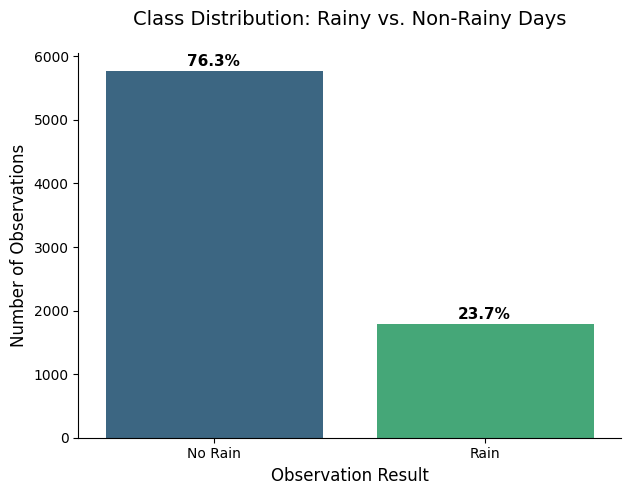

In [14]:
# Visualizing the Class Imbalance

plt.figure(figsize=(7, 5))

y_plot = y.map({'No': 0, 'Yes': 1}) if y.dtype == 'object' else y

ax = sns.countplot(x=y_plot, hue=y_plot, palette='viridis', legend=False, order=[0, 1])

# 1. Adding descriptive labels
plt.xticks(ticks=[0, 1], labels=['No Rain', 'Rain'])

# 2. Add percentage annotations on top of the bars
total = len(y)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x_coord = p.get_x() + p.get_width() / 2 - 0.1   # Center the text
    y_coord = p.get_height() + (total * 0.01)       # Offset text above bar
    ax.annotate(percentage, (x_coord, y_coord), size=11, fontweight='bold')

plt.title('Class Distribution: Rainy vs. Non-Rainy Days', fontsize=14, pad=20)
plt.xlabel('Observation Result', fontsize=12)
plt.ylabel('Number of Observations', fontsize=12)

# Despine to make it look cleaner
sns.despine()

plt.show()

### What can we conclude from these counts?
- How often does it rain annualy in the Melbourne area?
- How accurate would we be if we just assumed it won't rain every day?
- Is this a balanced dataset?
- Next steps?

This is what we can derive from the distribution counts:

* Based on the dataset, on average it rains **23.7%** of the time in the Melbourne area. This is the result of dividing the number of 'Yes' by the total number of observations (1791 / (1791 + 5766)).
* Without considering the seasons of the year, I would say that I would be 76.3% correct when saying it won't rain every day.
* No, it is not a balanced dataset as there are roughly 3 negative outcomes (no rain today) for each positive outcome (rain today).
* We could consider stratifying the data during the train / test split to keep the same 76/24 ratio, preventing the model from being evaluated on unrepresentative data.

## Split the Data into Training and Test Sets Ensuring Target Stratification


In [15]:
# Splitting data into training and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Standardizing the Target Variable
We will convert all 'No' values to **0** and all 'Yes' values to **1**. This will help with model execution as some do expect numeric values only.

In [16]:
# Standardizing the target variable for all models

# No -> 0, Yes -> 1
y_train = y_train.map({'No': 0, 'Yes': 1})
y_test = y_test.map({'No': 0, 'Yes': 1})

## Define Preprocessing Transformers for Numerical and Categorical Features
### Automatically detect numerical and categorical columns and assign them to separate numeric and categorical features

In [17]:
# Detecting numerical and categorical columns and assign them to separate numeric and categorical features

numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()  
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

### Define separate transformers for both feature types and combine them into a single preprocessing transformer


In [18]:
# Defining separate transformers for both feature types 

# Scale the numeric features
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# One-hot encode the categoricals 
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

### Combine the transformers into a single preprocessing column transformer

In [19]:
# Combining the transformers into a single preprocessing column transformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## Model 1: Random Forest

### Create a pipeline by combining the preprocessing with a Random Forest classifier instance

In [20]:
# Creating a pipeline by combining the preprocessing with a Random Forest classifier

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

### Define a parameter grid to use in a cross validation grid search model optimizer

In [21]:
# Defining a parameter grid to use in a cross validation grid search model optimizer

param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

### Pipeline usage in crossvalidation
We could use the pipeline repeatedly within the crossvalidation by fitting on each internal training fold and predicting on its corresponding validation fold.

### Perform grid search cross-validation and fit the best model to the training data
#### Select a cross-validation method ensuring target stratification during validation

In [22]:
# Selecting a cross-validation method, ensuring target stratification during validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Instantiate and fit GridSearchCV to the pipeline

In [23]:
# Instantiating and fitting GridSearchCV to the pipeline

grid_search_rf = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1_macro', n_jobs=1, verbose=2)  
grid_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.5s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.5s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

### Print the best parameters and best crossvalidation score

In [24]:
# Printing the best parameters and best crossvalidation score

print("\nBest parameters found: ", grid_search_rf.best_params_)
print("Best cross-validation score: {:.2f}".format(grid_search_rf.best_score_))


Best parameters found:  {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best cross-validation score: 0.76


### Display the model's estimated score

In [25]:
# Displaying the model's estimated score

test_score = grid_search_rf.score(X_test, y_test)  
print("Test set score: {:.2f}".format(test_score))

Test set score: 0.75


So we have a reasonably accurate classifer, which is expected to correctly predict about **76%** of the time whether it will rain today in the Melbourne area.  
But careful here. Let's take a deeper look at the results.

The best model is stored within the gridsearch object.


### Get the model predictions from the grid search estimator on the unseen data

In [26]:
# Getting the model predictions from the grid search estimator on the unseen data

rf_predictions = grid_search_rf.predict(X_test)

### Print the classification report

In [27]:
# Printing the classification report and saving scores

# 1. Get Accuracy score
rf_accuracy = round(accuracy_score(y_test, rf_predictions), 2)

# 2. Get Overall (Macro) F1
rf_f1_macro = round(f1_score(y_test, rf_predictions, average='macro'), 2)

# 3. Get the 'Yes' F1 (This targets index 1 or 'Yes')
rf_f1_yes = round(f1_score(y_test, rf_predictions, pos_label=1), 2)

# 4. Get the Recall specifically for the 'Yes' class
rf_recall_yes = round(recall_score(y_test, rf_predictions, pos_label=1), 2)

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions, target_names=['No', 'Yes']))


Classification Report:
              precision    recall  f1-score   support

          No       0.86      0.95      0.90      1154
         Yes       0.75      0.51      0.60       358

    accuracy                           0.84      1512
   macro avg       0.80      0.73      0.75      1512
weighted avg       0.83      0.84      0.83      1512



### Best Parameters for Random Forest

In [28]:
# Best Parameters for Random Forest

clean_rf_params = {k.replace('classifier__', ''): v for k, v in grid_search_rf.best_params_.items()}
formatted_rf_params = ", ".join([f"{k}: {v}" for k, v in clean_rf_params.items()])
print("Random Forest Optimization Results:\n")
print(f"Optimal Parameters: {formatted_rf_params}")

Random Forest Optimization Results:

Optimal Parameters: max_depth: None, min_samples_split: 5, n_estimators: 100


### Plot the confusion matrix 

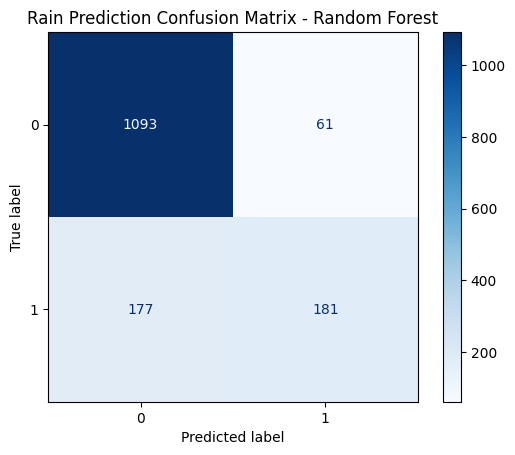

In [29]:
# Plotting the confusion matrix

conf_matrix = confusion_matrix(y_test, rf_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Rain Prediction Confusion Matrix - Random Forest')
plt.show()

Let's consider whether the results indicate a good predictor of rainfall.

What is the true positive rate? 

The true positive rate is **51.1%** This is the result of dividing true positives by the sum of true positives and false negatives.

### Feature importances
In order to obtain the categorical feature importances, we have to work our way backward through the modelling pipeline to associate the feature importances with their original input variables, not the one-hot encoded ones. We don't need to do this for the numeric variables because we didn't modify their names in any way.  
We went from categorical features to one-hot encoded features, using the 'cat' column transformer.
 
Let's get all of the feature importances and associate them with their transformed features

### Extract the feature importances

In [30]:
# Extracting the feature importances

feature_importances = grid_search_rf.best_estimator_['classifier'].feature_importances_

Now let's extract the feature importances and plot them as a bar graph.


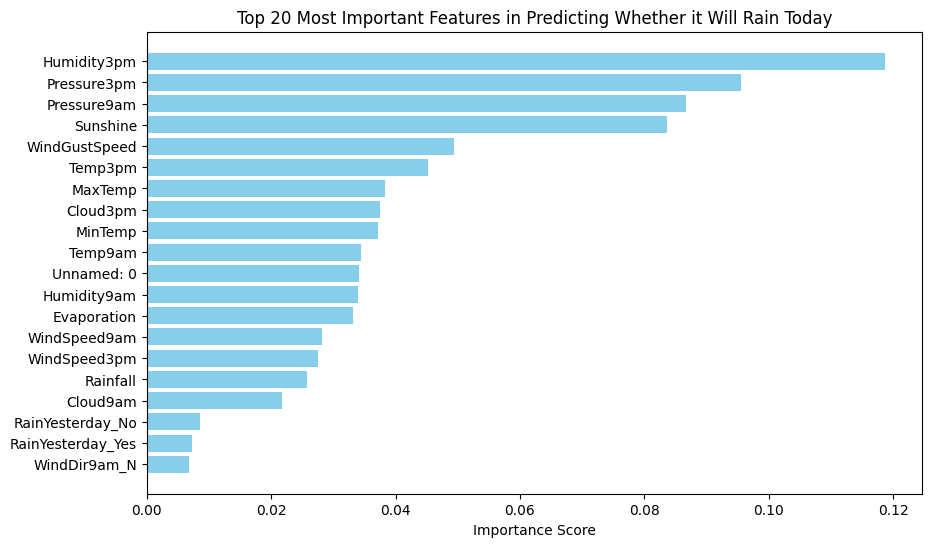

In [31]:
# Extracting the feature importances and plotting them as a bar graph

# Combine numeric and categorical feature names
feature_names = numeric_features + list(grid_search_rf.best_estimator_['preprocessor']
                                        .named_transformers_['cat']
                                        .named_steps['onehot']
                                        .get_feature_names_out(categorical_features))

feature_importances = grid_search_rf.best_estimator_['classifier'].feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importances
                             }).sort_values(by='Importance', ascending=False)

N = 20  # Change this number to display more or fewer features
top_features = importance_df.head(N)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature on top
plt.title(f'Top {N} Most Important Features in Predicting Whether it Will Rain Today')
plt.xlabel('Importance Score')
plt.show()

What is the most important feature for predicting whether it will rain based on the feature importance bar graph? 

Based on the chart, the most important feature to determine if it is going to rain today is **Humidity at 3 PM**.

## Model 2: Logistic Regression

In practice we would want to try out different models and even revisit the data analysis to improve
the model's performance. Maybe we can engineer better features, drop irrelevant or redundant ones, project the data onto a dimensional feature space, or impute missing values to be able to use more data. We can also try a larger set of parameters to define the search grid, or even engineer new features using cluster analysis. We can even include the clustering algorithm's hyperparameters in the search grid.

With Scikit-learn's pipeline and GridSearchCV classes, this is easy to do in a few steps.

### Update the pipeline and create a new parameter grid
Let's update the pipeline and create a new parameter grid and train a Logistic Regression model and compare the performance of the two models. We'll need to replace the clasifier with LogisticRegression.

In [32]:
# Updating the pipeline and the parameter grid to use a Logistic Regression Model

# Replace RandomForestClassifier with LogisticRegression
pipeline.set_params(classifier=LogisticRegression(random_state=42))

# Define a new grid with Logistic Regression parameters
if version.parse(sklearn.__version__) >= version.parse("1.8"):
    lr_param_grid = {
        'classifier__solver': ['liblinear'],
        'classifier__l1_ratio': [0, 1],
        'classifier__class_weight': [None, 'balanced']
    }
else:
    lr_param_grid = {
        'classifier__solver': ['liblinear'],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__class_weight': [None, 'balanced']
    }

# Depending on the version of scikit-learn use this group of parameters or the one below
#lr_param_grid = {
#    'classifier__solver': ['liblinear'],
#    'classifier__l1_ratio': [0, 1],
#    'classifier__class_weight': [None, 'balanced']    
#}

#lr_param_grid = {
#    'classifier__solver': ['liblinear'],
#    'classifier__penalty': ['l1', 'l2'],
#    'classifier__class_weight': [None, 'balanced']
#}

# Creating a Grid Search object
grid_search_lr = GridSearchCV(pipeline, lr_param_grid, cv=cv, scoring='f1_macro', n_jobs=1)

# Fit the updated pipeline with LogisticRegression
grid_search_lr.fit(X_train, y_train)

# Make predictions
lr_predictions = grid_search_lr.predict(X_test)

###  Compare the results to the previous model
Display the clasification report and the confusion matrix for the new model and compare the results with the previous model.


In [33]:
# Comparing the results to your previous model and saving the scores

# Get Accuracy score
lr_accuracy = round(accuracy_score(y_test, lr_predictions), 2)

# Get Overall (Macro) F1
lr_f1_macro = round(f1_score(y_test, lr_predictions, average='macro'), 2)

# Get the 'Yes' F1 (This targets index 1 or 'Yes')
lr_f1_yes = round(f1_score(y_test, lr_predictions, pos_label=1), 2)

# Get the Recall specifically for the 'Yes' class
lr_recall_yes = round(recall_score(y_test, lr_predictions, pos_label=1), 2)

print(classification_report(y_test, lr_predictions, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.86      0.93      0.89      1154
         Yes       0.69      0.51      0.59       358

    accuracy                           0.83      1512
   macro avg       0.77      0.72      0.74      1512
weighted avg       0.82      0.83      0.82      1512



### Best Parameters for Logistic Regression

In [34]:
# Best Parameters for Logistic Regression

clean_lr_params = {k.replace('classifier__', ''): v for k, v in grid_search_lr.best_params_.items()}
formatted_lr_params = ", ".join([f"{k}: {v}" for k, v in clean_lr_params.items()])
print("Logistic Regression Optimization Results:\n")
print(f"Optimal Parameters: {formatted_lr_params}")

Logistic Regression Optimization Results:

Optimal Parameters: class_weight: None, l1_ratio: 0, solver: liblinear


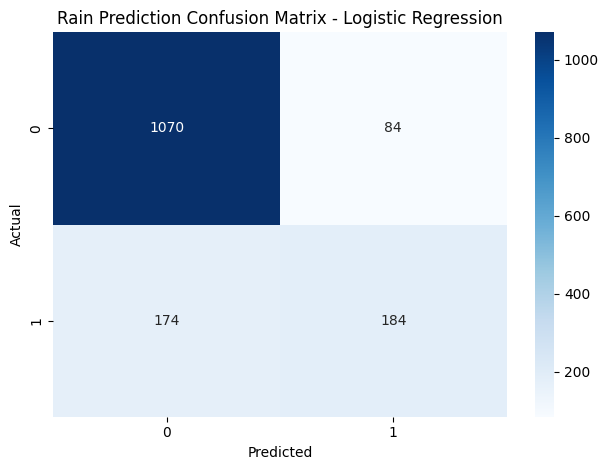

In [35]:
# Generate the confusion matrix 

conf_matrix = confusion_matrix(y_test, lr_predictions)

plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')

# Set the title and labels
plt.title('Rain Prediction Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.tight_layout()
plt.show()

What can we conclude about the model performance? 

Let's compare the accuracy and true positive rate of rainfall predictions between the Logistic Regression model and the Random Forest Classifier model:

* The Recall score (or true positive rate) for Logistic Regression is **51.4%** whereas Random Forest has a Recall score of 51.1%
* In terms of accuracy, Logistic Regression has a 83% rate whereas Random Forest has a rate of **84%**
* Regarding precision, Logistic Regression has a 69% rate whereas Random Forest has a rate of **75%**

Based on these results, we can conclude that Random Forest performed slightly better than Logistic Regression, especially when it actually predicts rain. However, both models struggle to predict rain almost 50% of the time that it actually rains. This suggests that the models prioritize avoiding 'false alarms' over catching every single rain event.

## Model 3: Support Vector Machine (SVM)

In addition to Random Forest and Logistic Regression, we will test how SVM performs and generate the corresponding scores.

In [36]:
# Initialize the model
# Probability=True allows you to calculate LogLoss/Predict_proba later if needed
# Replace LogisticRegression with SVM
pipeline.set_params(classifier=SVC(kernel='rbf', probability=True, random_state=42))

# Define a new grid with SVM parameters
svm_param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__gamma': ['scale', 'auto']
}

# Creating a Grid Search object
grid_search_svm = GridSearchCV(pipeline, svm_param_grid, cv=cv, scoring='f1_macro', n_jobs=1)

# Fit the updated pipeline with SVM
grid_search_svm.fit(X_train, y_train)

# Make predictions
svm_predictions = grid_search_svm.predict(X_test)

# Get Accuracy score
svm_accuracy = round(accuracy_score(y_test, svm_predictions), 2)

# Get Overall (Macro) F1
svm_f1_macro = round(f1_score(y_test, svm_predictions, average='macro'), 2)

# Get the 'Yes' F1 (This targets index 1 or 'Yes')
svm_f1_yes = round(f1_score(y_test, svm_predictions, pos_label=1), 2)

# Get the Recall specifically for the 'Yes' class
svm_recall_yes = round(recall_score(y_test, svm_predictions, pos_label=1), 2)

# Evaluation
print(classification_report(y_test, svm_predictions, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.86      0.95      0.90      1154
         Yes       0.75      0.49      0.59       358

    accuracy                           0.84      1512
   macro avg       0.80      0.72      0.75      1512
weighted avg       0.83      0.84      0.83      1512



### Best Parameters for SVM

In [37]:
# Best Parameters for SVM

clean_svm_params = {k.replace('classifier__', ''): v for k, v in grid_search_svm.best_params_.items()}
formatted_svm_params = ", ".join([f"{k}: {v}" for k, v in clean_svm_params.items()])
print("SVM Optimization Results:\n")
print(f"Optimal Parameters: {formatted_svm_params}")

SVM Optimization Results:

Optimal Parameters: C: 10, gamma: auto


### Showing the Confusion Matrix for SVM

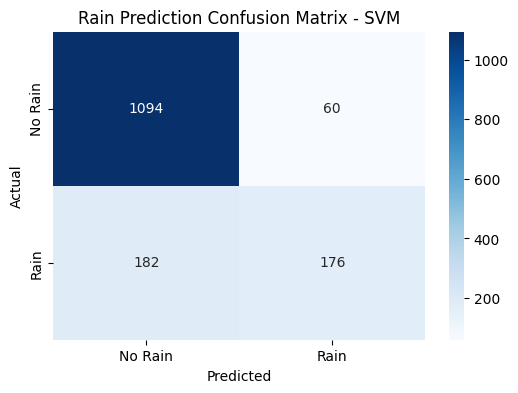

In [38]:
# Generate the matrix
cm_svm = confusion_matrix(y_test, svm_predictions)

# Plotting
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Rain', 'Rain'], 
            yticklabels=['No Rain', 'Rain'])
plt.title('Rain Prediction Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

For SVM, the true positive rate is **49.4%**.

## Model 4: XGBoost

We will try XGBoost which is an implementaion of gradient-boosted decision trees.

In [39]:
# Initialize the model

# Updating the pipeline with the new model
pipeline.set_params(classifier=XGBClassifier(random_state=42))

# Define a new grid with XGB parameters
xgb_param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [3, 6],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__scale_pos_weight': [1, 3.2]
}

# Creating a Grid Search object
grid_search_xgb = GridSearchCV(pipeline, xgb_param_grid, cv=cv, scoring='f1_macro', n_jobs=1)

# Fit the updated pipeline with XGB
grid_search_xgb.fit(X_train, y_train)

# Make predictions
xgb_predictions = grid_search_xgb.predict(X_test)

# Get Accuracy score
xgb_accuracy = round(accuracy_score(y_test, xgb_predictions), 2)

# Get Overall (Macro) F1
xgb_f1_macro = round(f1_score(y_test, xgb_predictions, average='macro'), 2)

# Get the 'Yes' F1 (This targets index 1 or 'Yes')
xgb_f1_yes = round(f1_score(y_test, xgb_predictions, pos_label=1), 2)

# Get the Recall specifically for the 'Yes' class
xgb_recall_yes = round(recall_score(y_test, xgb_predictions, pos_label=1), 2)

# Evaluation
#print(classification_report(y_test, xgb_predictions))
print(classification_report(y_test, xgb_predictions, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.91      0.85      0.88      1154
         Yes       0.61      0.73      0.66       358

    accuracy                           0.82      1512
   macro avg       0.76      0.79      0.77      1512
weighted avg       0.84      0.82      0.83      1512



### Best Parameters for XGBoost

In [40]:
# Best Parameters for XGBoost

clean_xgb_params = {k.replace('classifier__', ''): v for k, v in grid_search_xgb.best_params_.items()}
formatted_xgb_params = ", ".join([f"{k}: {v}" for k, v in clean_xgb_params.items()])
print("XGBoost Optimization Results:\n")
print(f"Optimal Parameters: {formatted_xgb_params}")

XGBoost Optimization Results:

Optimal Parameters: learning_rate: 0.1, max_depth: 6, n_estimators: 100, scale_pos_weight: 3.2


### Showing the Confusion Matrix for XGBoost

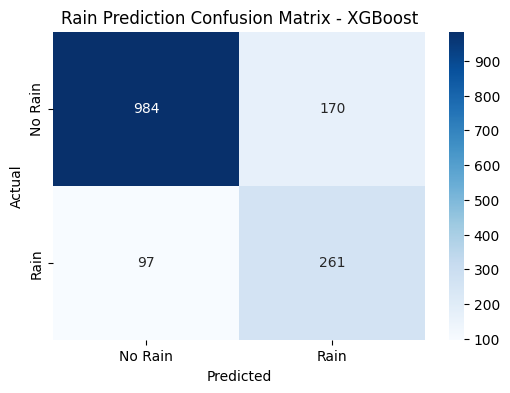

In [41]:
# Generate the matrix
cm_xgb = confusion_matrix(y_test, xgb_predictions)

# Plotting
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Rain', 'Rain'], 
            yticklabels=['No Rain', 'Rain'])
plt.title('Rain Prediction Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

For the XGBoost model, the true positive rate is **73.2%**.

## Comparison of the Four Models

### Showing the Precision-Recall Curve

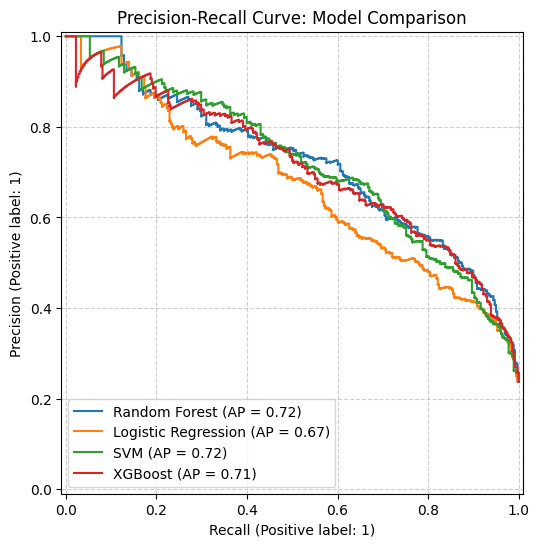

In [42]:
# Set up the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each model's curve
# Note: Using the grid_search objects directly because they contain the best_estimator_
PrecisionRecallDisplay.from_estimator(grid_search_rf, X_test, y_test, ax=ax, name="Random Forest")
PrecisionRecallDisplay.from_estimator(grid_search_lr, X_test, y_test, ax=ax, name="Logistic Regression")
PrecisionRecallDisplay.from_estimator(grid_search_svm, X_test, y_test, ax=ax, name="SVM")
PrecisionRecallDisplay.from_estimator(grid_search_xgb, X_test, y_test, ax=ax, name="XGBoost")

plt.title('Precision-Recall Curve: Model Comparison')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Characteristics of the Models Used in This Project

| Model | Characteristic | The Weather Logic | Strength |
| :------------------- | :---------------- | :------------------------------------------ | :----- |
| Random Forest  | Ensemble / Hierarchical | Combines predictions from multiple decision trees to identify weather patterns associated with rainfall | Handles nonlinear relationships well |
| Logistic Regression  | Linear | Models the relationship between weather variables and the probability of rain using a linear decision boundary | Interpretable baseline model |
| SVM                  | Geometric         | Identifies an optimal boundary in feature space to separate rainy and non-rainy conditions   | Effective in high-dimensional spaces |
| XGBoost | Gradient Boosting | Iteratively improves predictions by learning from previous model errors, helping capture more complex rainfall patterns | Strong performance on imbalanced patterns |
    

Each model offers different trade-offs between interpretability, complexity, computational cost, and ability to capture nonlinear patterns. Comparing multiple approaches helped identify the most effective model for handling the imbalanced rainfall dataset.

### Best Parameter Table Summary
Next we can see the best parameters for each of the optimized models to get an idea of how the optimization found the best parameters in each case.

In [43]:
# Creating a param summary dictionary

pd.set_option('display.max_colwidth', None)

param_data = {
    'Model': ['Random Forest', 'Logistic Regression', 'SVM', 'XGBoost'],
    'Key Optimal Hyperparameters': [formatted_rf_params, formatted_lr_params, formatted_svm_params, formatted_xgb_params],
}

param_summary_df = pd.DataFrame(param_data)
param_summary_df.set_index('Model', inplace=True)

# Use this version to show it in GitHub
param_summary_df


,Key Optimal Hyperparameters
Model,
Random Forest,"max_depth: None, min_samples_split: 5, n_estimators: 100"
Logistic Regression,"class_weight: None, l1_ratio: 0, solver: liblinear"
SVM,"C: 10, gamma: auto"
XGBoost,"learning_rate: 0.1, max_depth: 6, n_estimators: 100, scale_pos_weight: 3.2"


### Score Comparison
The following table will show the summary from the models that have been used in this project.

In [44]:
# Creating a summary dictionary

data = {
    'Model': ['Random Forest', 'Logistic Regression', 'SVM', 'XGBoost'],
    'Accuracy': [rf_accuracy, lr_accuracy, svm_accuracy, xgb_accuracy],
    'Recall (Rain Events)': [rf_recall_yes, lr_recall_yes, svm_recall_yes, xgb_recall_yes],
    'F1-Score (Overall)': [rf_f1_macro, lr_f1_macro, svm_f1_macro, xgb_f1_macro],
    'F1-Score (Rain Events)': [rf_f1_yes, lr_f1_yes, svm_f1_yes, xgb_f1_yes]
}

summary_df = pd.DataFrame(data)
summary_df.set_index('Model', inplace=True)

# Use this version to show it in GitHub
summary_df

# Use the below if you are running locally or on Kaggle
# Displaying the styled dataframe
#summary_df.style.highlight_max(axis=0, color='lightgreen').highlight_min(axis=0, color='skyblue')\
#          .format("{:.2f}", subset=['Accuracy', 'Recall (Rain Events)', 'F1-Score (Overall)', 'F1-Score (Rain Events)'])\
#          .set_caption("<br><b>Model Comparison Summary</b><br>(Green: Best Performance | Blue: Lowest Metric)")

,Accuracy,Recall (Rain Events),F1-Score (Overall),F1-Score (Rain Events)
Model,,,,
Random Forest,0.84,0.51,0.75,0.60
Logistic Regression,0.83,0.51,0.74,0.59
SVM,0.84,0.49,0.75,0.59
XGBoost,0.82,0.73,0.77,0.66


# Final Conclusion and Model Selection
After a comprehensive evaluation of **Logistic Regression**, **Random Forest**, **Support Vector Machines (SVM)**, and **XGBoost**, the XGBoost Classifier is the selected model for this project.

Key Findings:

* **Superior Performance:** For what we can consider the most important metric (predicting a rainy day), XGBoost achieved the highest F1-Score at **0.66**. It also outperformed the other models significantly by obtaining a Recall score of **0.73**.

* **Imbalance Resilience:** In the critical metric of Rain Event F1-Score (0.66), XGBoost outperformed Random Forest, Logistic Regression, and SVM, proving it is better at handling the class imbalance in the Melbourne climate data.

* **Practical Application:** While SVM and Random Forest were the most "conservative" (highest precision and low recall), XGBoost provides the best balance. It offers the highest probability of correctly identifying a rainy day while maintaining a professional balance with false alarms.

* **Precision-Recall Curve:** The curve visually confirms that Random Forest, SVM, and XGBoost deliver a similar global performance with Average Precision (AP) scores between **0.72** and **0.73**, significantly outperforming Logistic Regression. However, through targeted hyperparameter tuning and class weighting, the **XGBoost** model proved to be the most effective in an operational context. While maintaining an AP comparable to the other top models, it successfully maximized **Recall for Rain Events (0.73)**, providing a more reliable predictive tool for high-impact weather events compared to the baseline classifiers.

**Final Verdict:** While global metrics like Average Precision are competitive across all top models, **XGBoost** is the superior choice for stakeholders. By successfully addressing class imbalance, it provides a **43%** improvement in Recall for rain events over the baseline models, making it the most actionable and dependable tool for rainfall prediction in the Melbourne area.

---
#### Original Lab Author(s)
<a href="https://www.linkedin.com/in/jpgrossman/" target="_blank">Jeff Grossman</a>

#### Other Contributor(s)
<a href="https://www.linkedin.com/in/abhishek-gagneja-23051987/" taget="_blank">Abhishek Gagneja</a>

© IBM Corporation. All rights reserved.